# Step 10 — the interferon score, federated

**Data type: RNA_array** (GSE65391). **Reads:** `step09_site_{A,B,C}.rds`. **Writes:** `step10_site_{A,B,C}.rds`,
`figures/fig10_RNA_array_ifn_by_stage.png`.

Type I interferon drives much of pediatric lupus. For each sample, each score gene is expressed as a
z-score against the healthy children (how many healthy standard deviations above the healthy mean),
and the score is the median across the genes. The default is the six-gene score in
`genes/ifn-type1-6.txt`. The 28-gene interferonopathy panel is scored too once
`genes/ifn-interferonopathy-28.txt` holds its genes.

**Federated.** The healthy reference is a mean and an SD per gene. Each site sends, for its own healthy
children (first visit each, so no child counts twice), a count, sum and sum of squares per score gene:
18 numbers. The coordinator returns the pooled mean and SD, and each site scores its own samples.

In [1]:
source("../src/paths.R")
source("../src/endotypes.R")
source("../src/federation.R")
start_log("10")
score_panel <- function(genes, label) {
  ref_msgs <- lapply(setNames(SITES, SITES), function(s) {
    d <- readRDS(site_file("09", s)); m <- d$meta
    h <- m[m$disease == "Healthy", ]; h <- h[order(h$subject, h$visit), ]
    ref <- rownames(h)[!duplicated(h$subject)]
    send(site_suff(d$E[genes, ref, drop = FALSE]), s, paste(label, "healthy reference sums"), ncol(d$E))
  })
  ref <- pool_suff(ref_msgs)
  list(mean = ref$mean, sd = sqrt(ref$var), n_reference = ref$n)
}
ifn6 <- read_gene_set("ifn-type1-6.txt")
REF6 <- score_panel(ifn6, "ifn6")
round(rbind(mean = REF6$mean, sd = REF6$sd), 2)
REF6$n_reference

,IFI27,IFI44L,IFIT1,ISG15,RSAD2,SIGLEC1
mean,7.32,6.63,7.99,9.06,7.41,3.34
sd,1.81,1.81,1.72,1.34,1.30,0.29


[1] 46

In [2]:
panel28 <- read_gene_set("ifn-interferonopathy-28.txt")
if (length(panel28)) {
  panel28 <- intersect(panel28, rownames(readRDS(site_file("09", "A"))$E))
  REF28 <- score_panel(panel28, "ifn28")
} else message("genes/ifn-interferonopathy-28.txt holds no genes yet: 28-gene score skipped")

genes/ifn-interferonopathy-28.txt holds no genes yet: 28-gene score skipped



## Each site scores its own samples

In [3]:
median_z <- function(E, ref) apply((E[names(ref$mean), , drop = FALSE] - ref$mean) / ref$sd, 2, median)
for (s in SITES) {
  d <- readRDS(site_file("09", s))
  d$meta$ifn_score <- median_z(d$E, REF6)
  if (length(panel28)) d$meta$ifn_score_28 <- median_z(d$E, REF28)
  saveRDS(d, site_file("10", s))
}

## Oracle — possible only because this is a simulation

The same score computed on all samples in one place, with the reference taken from all healthy
children together. It is used only as a check.

In [4]:
all_E <- do.call(cbind, lapply(SITES, function(s) readRDS(site_file("09", s))$E[ifn6, ]))
all_m <- do.call(rbind, lapply(SITES, function(s) readRDS(site_file("10", s))$meta))
h <- all_m[all_m$disease == "Healthy", ]; h <- h[order(h$subject, h$visit), ]
central <- ifn_score(all_E, ifn6, reference = colnames(all_E) %in% rownames(h)[!duplicated(h$subject)])
gap <- max(abs(central[rownames(all_m), "ifn_score"] - all_m$ifn_score))
stopifnot(gap < 1e-10)
cat(sprintf("GATE PASSED: federated score equals the central score to %.1e\n", gap))
rm(all_E, all_m)

GATE PASSED: federated score equals the central score to 1.2e-13


## Does the score behave? A picture from histograms

Each site sends, for each SLEDAI category, a histogram of its scores (bins of 0.25). The coordinator
adds them up. The medians below are read from the pooled histograms, so they are exact to within one
bin.

In [5]:
BREAKS <- seq(-4, 8, by = 0.25)
GROUPS <- c("healthy", SLEDAI_LEVELS)
hists <- lapply(SITES, function(s) {
  m <- readRDS(site_file("10", s))$meta
  g <- factor(ifelse(m$disease == "Healthy", "healthy", as.character(m$stage)), levels = GROUPS)
  x <- pmin(pmax(m$ifn_score, -4), 8)
  send(sapply(GROUPS, function(k) hist(x[g %in% k], BREAKS, plot = FALSE)$counts),
       s, "interferon score histogram by stage", nrow(m))
})
H <- Reduce(`+`, hists)
mids <- head(BREAKS, -1) + 0.125
med  <- apply(H, 2, function(h) mids[which(cumsum(h) >= sum(h) / 2)[1]])
rbind(samples = colSums(H), approximate_median = med)

,healthy,none,mild,moderate,high,very high
samples,48.000,93.000,390.000,277.000,127.000,37.000
approximate_median,-0.375,2.375,2.625,2.875,2.875,3.125


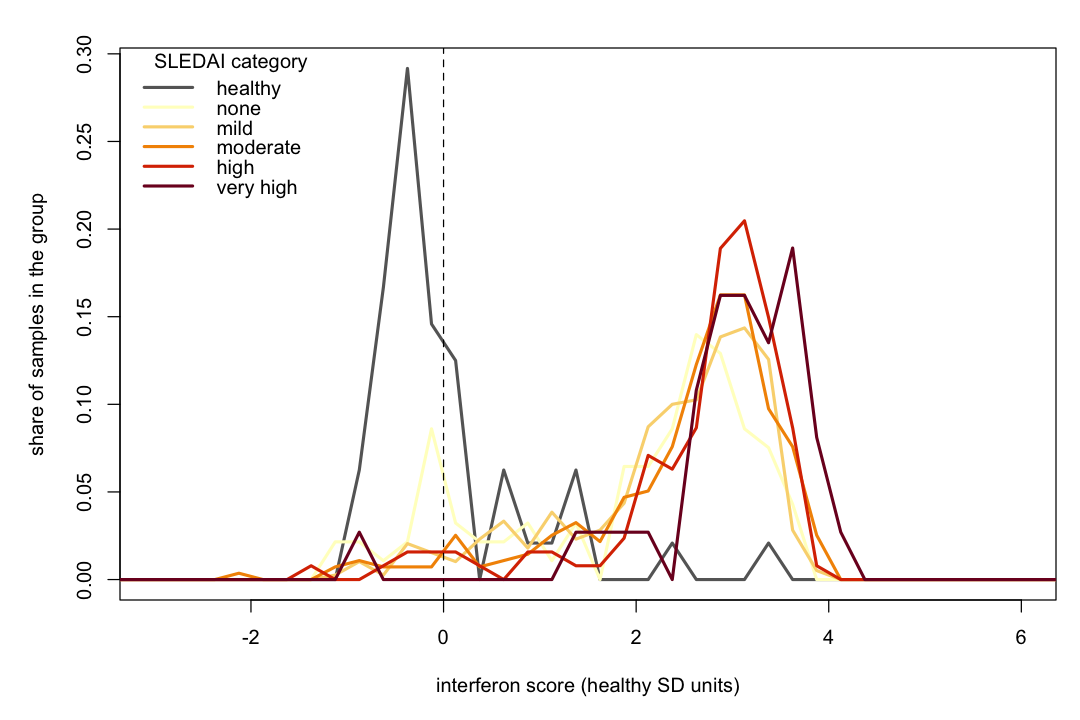

In [6]:
draw_ifn <- function() {
  cols <- c("grey40", hcl.colors(5, "YlOrRd", rev = TRUE))
  par(mar = c(5, 5, 2, 1))
  plot(NULL, xlim = c(-3, 6), ylim = c(0, max(sweep(H, 2, colSums(H), "/"))),
       xlab = "interferon score (healthy SD units)", ylab = "share of samples in the group")
  for (k in seq_along(GROUPS)) lines(mids, H[, k] / sum(H[, k]), col = cols[k], lwd = 2.5)
  abline(v = 0, lty = 2)
  legend("topleft", GROUPS, col = cols, lwd = 2.5, bty = "n", title = "SLEDAI category")
}
png(fig("fig10_RNA_array_ifn_by_stage.png"), width = 1400, height = 900, res = 150); draw_ifn(); invisible(dev.off())
options(repr.plot.width = 9, repr.plot.height = 6); draw_ifn()

## Findings

The federated score equals the central score exactly. Healthy children centre near zero by
construction. Children with SLE sit well above them in every SLEDAI category, including visits with
no clinical activity, and the score rises only a little with activity. The interferon signature marks
the disease more than the flare, which is why it may define an endotype rather than a stage.